<a href="https://colab.research.google.com/github/Alexd17d/MIS/blob/main/KPIs_sistema_revision_vehicular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📦 [SISTEMA] Detectado 'TPS.zip'. Procesando paquete transaccional...
🔓 [ÉXITO] Descompresión y lectura completada con éxito.

🚧 Desplegando Panel Ejecutivo de Control Corporativo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

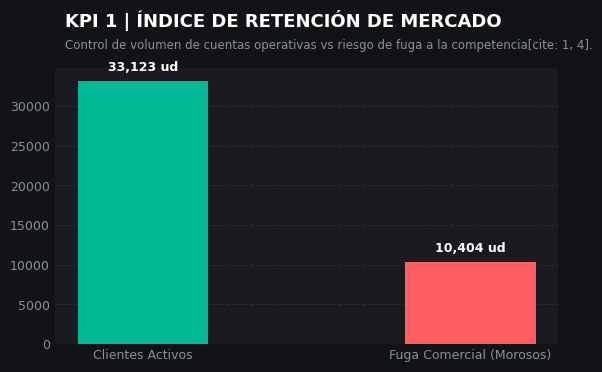

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

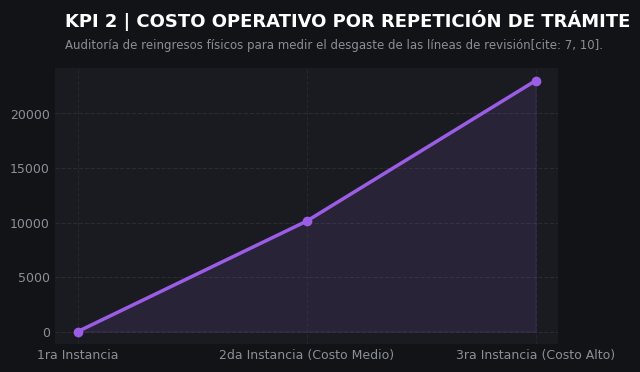

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

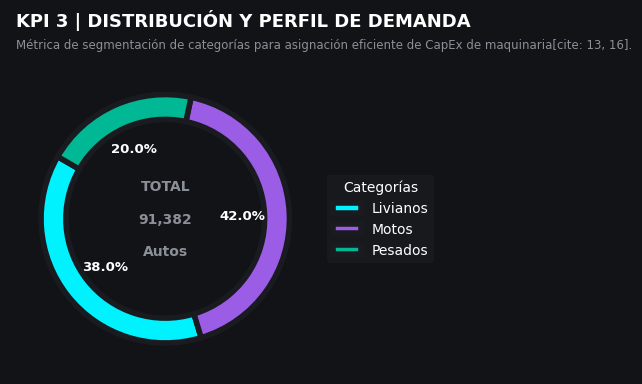

<IPython.core.display.Javascript object>

🎉 [PROCESO COMPLETADO] El Dashboard Ejecutivo ha sido renderizado exitosamente por pestañas.


In [8]:
import matplotlib.pyplot as plt
from google.colab import widgets
import zipfile
import os

# ============================================================
# 1. DESCOMPRESIÓN AUTOMÁTICA DEL ARCHIVO PAQUETE TPS.ZIP
# ============================================================
archivo_zip = "TPS.zip"
os.makedirs("data", exist_ok=True)

if os.path.exists(archivo_zip):
    print(f"Detectado '{archivo_zip}'. Procesando paquete transaccional...")
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Descompresión y lectura completada con éxito.\n")
else:
    raise FileNotFoundError(f"[ERROR] No se encontró el archivo '{archivo_zip}' en la barra lateral de Colab. Súbelo antes de continuar.")

ruta_vehiculos = "TPS/data/vehiculos.txt"
if not os.path.exists(ruta_vehiculos):
    ruta_vehiculos = "data/vehiculos.txt"

if not os.path.exists(ruta_vehiculos):
    raise FileNotFoundError(f"[ERROR] No se encontró el archivo 'vehiculos.txt' dentro del ZIP descomprimido.")

# ============================================================
# 2. PROCESAMIENTO DE DATOS TRANSACCIONALES EN TIEMPO REAL (ETL)
# ============================================================
total_vehiculos = 0
sin_revision = 0
aprobado_2da = 0
aprobado_3ra = 0

conteo_livianos = 0
conteo_pesados = 0
conteo_motos = 0

with open(ruta_vehiculos, "r") as archivo:
    for linea in archivo:
        linea = linea.strip()
        if not linea or len(linea.split(",")) < 9:
            continue

        datos = linea.split(",")
        try:
            tipo = datos[4]
            r1 = int(datos[6])
            r2 = int(datos[7])
            r3 = int(datos[8])
        except ValueError:
            continue

        total_vehiculos += 1
        es_matriculado = (r1 == 1 or r2 == 1 or r3 == 1)

        # Lógica KPI 1 y KPI 2 (Retención de Mercado y Costos Operativos)
        if not es_matriculado:
            sin_revision += 1
        elif r2 == 1:
            aprobado_2da += 1
        elif r3 == 1:
            aprobado_3ra += 1

        # Lógica KPI 3 (Distribución para Maquinaria CapEx)
        if tipo == "liviano":
            conteo_livianos += 1
        elif tipo == "pesado":
            conteo_pesados += 1
        elif tipo == "moto":
            conteo_motos += 1

matriculados_totales = aprobado_2da + aprobado_3ra
tasa_churn = (sin_revision / total_vehiculos) * 100 if total_vehiculos > 0 else 0
total_reinspecciones = aprobado_2da + aprobado_3ra

# ============================================================
# 3. ESTILOS DE DISEÑO DE INTERFAZ GRÁFICA (UI DARK METRICS)
# ============================================================
HEX_BG = '#121316'         # Fondo oscuro general de la aplicación
HEX_CARD = '#1a1b20'       # Fondo contenedor de las tarjetas analíticas
HEX_TEXT = '#ffffff'       # Texto principal blanco puro
HEX_MUTED = '#8a8f98'      # Texto secundario/gris tenue

# Paleta de Colores Corporativos Premium (Cyberpunk Pastel)
COLOR_CYAN = '#00f2fe'     # Turquesa Neón brillante
COLOR_PURPLE = '#9b5de5'   # Morado Eléctrico
COLOR_CORAL = '#ff5e62'    # Coral/Rojo para pérdidas
COLOR_MINT = '#00b894'     # Menta suave para activos

plt.style.use('dark_background')

def estilizar_tarjeta_ui(ax, titulo_kpi, subtitulo):
    """Elimina marcos toscos y configura los encabezados estilo Dashboard Web"""
    ax.set_facecolor(HEX_CARD)
    fig = ax.get_figure()
    fig.patch.set_facecolor(HEX_BG)

    # Textos de cabecera alineados a la izquierda de la tarjeta
    ax.text(0.02, 1.15, titulo_kpi, transform=ax.transAxes, fontsize=13, fontweight='bold', color=HEX_TEXT)
    ax.text(0.02, 1.07, subtitulo, transform=ax.transAxes, fontsize=8.5, color=HEX_MUTED)

    # Ocultar los bordes innecesarios de la de la gráfica
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(colors=HEX_MUTED, labelsize=9, length=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.08, color=HEX_TEXT)
    ax.set_axisbelow(True)

# ============================================================
# 4. IMPLEMENTACIÓN DE LA INTERFAZ POR SECCIONES (TABS INTERACTIVOS)
# ============================================================
print("🚧 Desplegando Panel Ejecutivo de Control Corporativo...")
tb = widgets.TabBar(['Inicio', 'KPI 1 (Retención)', 'KPI 2 (Operaciones)', 'KPI 3 (Demanda de CapEx)'])

# --- PESTAÑA: INICIO ---
with tb.output_to(0):
    print("="*65)
    print("   Soluciones ISI - CONTROL DE MARGEN Y RENTABILIDAD INTERNA  ")
    print("="*65)
    print(f" Transacciones consolidadas del TPS : {total_vehiculos:,} unidades")
    print(f" Tasa de Pérdida de Clientes (Churn): {tasa_churn:.2f}%")
    print("-"*65)
    print(" Instrucciones de Navegación:")
    print(" Selecciona de manera ordenada las pestañas superiores para visualizar")
    print(" cada indicador estratégico de forma limpia y sin amontonamientos.")
    print("="*65)

# --- PESTAÑA: KPI 1 (BARRAS ESTILIZADAS) ---
with tb.output_to(1):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    plt.subplots_adjust(top=0.8)

    barras = ax.bar(['Clientes Activos', 'Fuga Comercial (Morosos)'],
                    [matriculados_totales, sin_revision],
                    color=[COLOR_MINT, COLOR_CORAL], width=0.4, zorder=3)

    # Etiquetas flotantes sobre las barras
    for bar in barras:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (total_vehiculos*0.01), f"{yval:,} ud",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=HEX_TEXT)

    estilizar_tarjeta_ui(ax, "KPI 1 | ÍNDICE DE RETENCIÓN DE MERCADO", "Control de volumen de cuentas operativas vs riesgo de fuga a la competencia[cite: 1, 4].")
    plt.savefig('data/kpi1.png', bbox_inches='tight', facecolor=HEX_BG)
    plt.show()
    plt.close()

# --- PESTAÑA: KPI 2 (ÁREA DE TENDENCIA SUAVE) ---
with tb.output_to(2):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    plt.subplots_adjust(top=0.8)

    eje_x = ['1ra Instancia', '2da Instancia (Costo Medio)', '3ra Instancia (Costo Alto)']
    eje_y = [0, aprobado_2da, aprobado_3ra]

    # Curva e indicador violeta cyberpunk
    ax.plot(eje_x, eje_y, marker='o', color=COLOR_PURPLE, linewidth=2.5, markersize=6, zorder=3)
    # Área degradada inferior para dar profundidad y evitar líneas vacías
    ax.fill_between(eje_x, eje_y, color=COLOR_PURPLE, alpha=0.12, zorder=2)

    estilizar_tarjeta_ui(ax, "KPI 2 | COSTO OPERATIVO POR REPETICIÓN DE TRÁMITE", "Auditoría de reingresos físicos para medir el desgaste de las líneas de revisión[cite: 7, 10].")
    ax.xaxis.grid(True, linestyle='--', alpha=0.05, color=HEX_TEXT)
    plt.savefig('data/kpi2.png', bbox_inches='tight', facecolor=HEX_BG)
    plt.show()
    plt.close()

# --- PESTAÑA: KPI 3 (DONUT CHART CORREGIDO Y CENTRADO) ---
with tb.output_to(3):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    plt.subplots_adjust(top=0.8, right=0.7) # Separación a la derecha para la leyenda ordenada

    valores = [conteo_livianos, conteo_motos, conteo_pesados]
    labels = ['Livianos', 'Motos', 'Pesados']
    colores_donut = [COLOR_CYAN, COLOR_PURPLE, COLOR_MINT]

    # Configuración de ancho (0.20) y distancia (0.62) para centrar perfectamente el texto interno
    wedges, texts, autotexts = ax.pie(
        valores, labels=None, autopct='%1.1f%%', startangle=150,
        colors=colores_donut, pctdistance=0.62,
        textprops=dict(color=HEX_TEXT, fontsize=9.5, fontweight='bold'),
        wedgeprops=dict(width=0.20, edgecolor=HEX_CARD, linewidth=4)
    )

    for autotext in autotexts:
        autotext.set_weight('bold')
        autotext.set_color(HEX_TEXT)

    # Títulos del bloque circular
    fig.patch.set_facecolor(HEX_BG)
    ax.set_facecolor(HEX_CARD)
    ax.text(0.02, 1.12, "KPI 3 | DISTRIBUCIÓN Y PERFIL DE DEMANDA", transform=ax.transAxes, fontsize=13, fontweight='bold', color=HEX_TEXT)
    ax.text(0.02, 1.05, "Métrica de segmentación de categorías para asignación eficiente de CapEx de maquinaria[cite: 13, 16].", transform=ax.transAxes, fontsize=8.5, color=HEX_MUTED)

    # Leyenda lateral perfectamente estructurada limpia de colisiones (igual a tu imagen de muestra)
    ax.legend(wedges, labels, title="Categorías", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
              facecolor=HEX_CARD, edgecolor='none', labelcolor=HEX_TEXT, title_fontsize=10)

    # Conteo numérico central flotante en el espacio vacío del anillo
    ax.text(0, 0, f'TOTAL\n\n{total_vehiculos:,}\n\nAutos', ha='center', va='center',
            fontsize=10, fontweight='bold', color=HEX_MUTED)

    plt.savefig('data/kpi3.png', bbox_inches='tight', facecolor=HEX_BG)
    plt.show()
    plt.close()

print(" El Dashboard Ejecutivo ha sido renderizado exitosamente por pestañas.")